# LFP spiking models performance with noisy inputs

We try:
- Gaussian noise to input signal (std=1)
- Gaussian noise to input signal (std=1) + random LGP phase shifts

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-10-30 12:39:24.012489: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 12:39:24.021805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-30 12:39:24.033159: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-30 12:39:24.036221: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-30 12:39:24.044767: I tensorflow/core/platform/cpu_feature_guar

### delay 400

In [7]:
condn_phrase = 'delay400.'
condn_num = ''

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)
theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
print(f'Number of 4Hz models: {len(theta4_dirs)}')

Number of 4Hz models: 31


In [4]:
# remove the 4Hz models that did not perform well on the delay=50 task

importlib.reload(ld)

spiking_perf = []
for model_name in theta4_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)
    
# remove low-perf models from theta4_dirs
high_perf_theta4_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_theta4_dirs.append(theta4_dirs[i])
        
theta4_dirs = high_perf_theta4_dirs
print(f'New number of 4Hz models: {len(theta4_dirs)}')

New number of 4Hz models: 24


In [5]:
# for SfN, we're choosing just 20 of these models...

i_model = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
theta4_dirs = [theta4_dirs[i] for i in i_model]
print(f'Final number of 4Hz models: {len(theta4_dirs)}')

Final number of 4Hz models: 20


In [8]:
# get all of the 4Hz and 8Hz models and their performances
importlib.reload(ld)
theta4_models, theta4_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              model_list = theta4_dirs,
                                              all_models_dir = all_models_dir)

Found 20 models with performance between -inf and inf


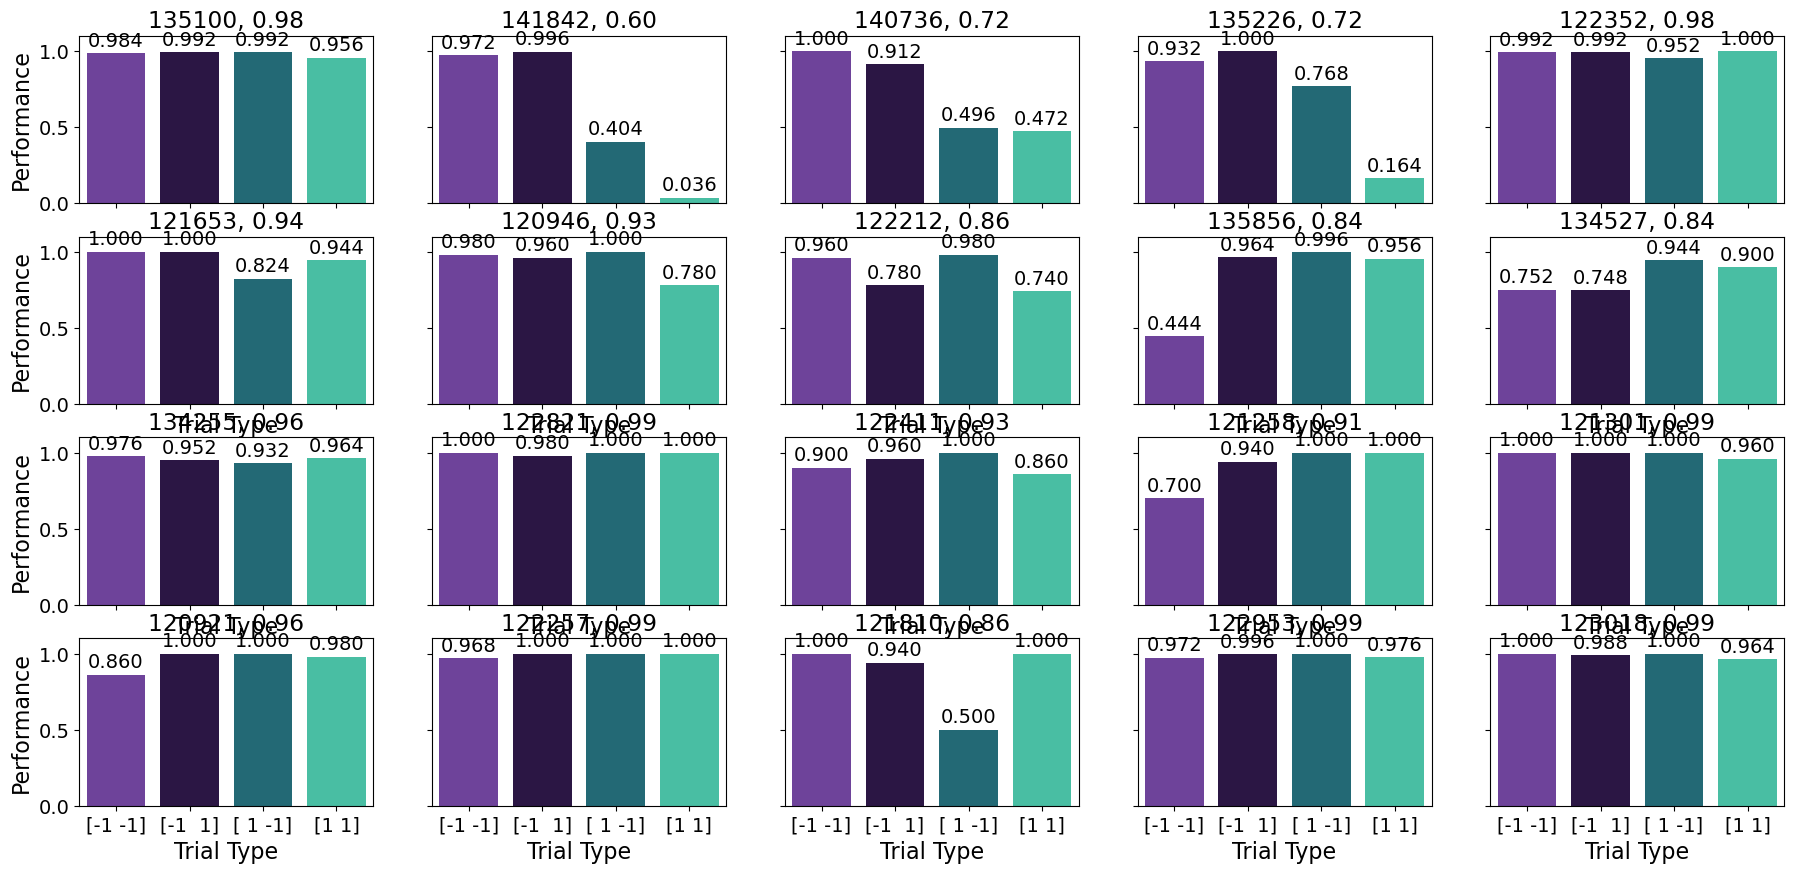

In [10]:
importlib.reload(bhv)

# make all font sizes larger
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 5, figsize=(22, 10), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model],
                               all_models_dir=all_models_dir)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    axs[i_model].set_title(f'{model_name[-6:]}, {np.mean(trial_perfs):.2f}')

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 5:
        axs[i].set_xlabel('')
    
    
# fig.suptitle(f'Jittered Models Performance for {condn_phrase} {condn_num}', fontsize=20)
plt.show()

### delay 400 + gaussian noise std 1

In [11]:
condn_phrase = 'delay400noisegaussian1.'
condn_num = ''

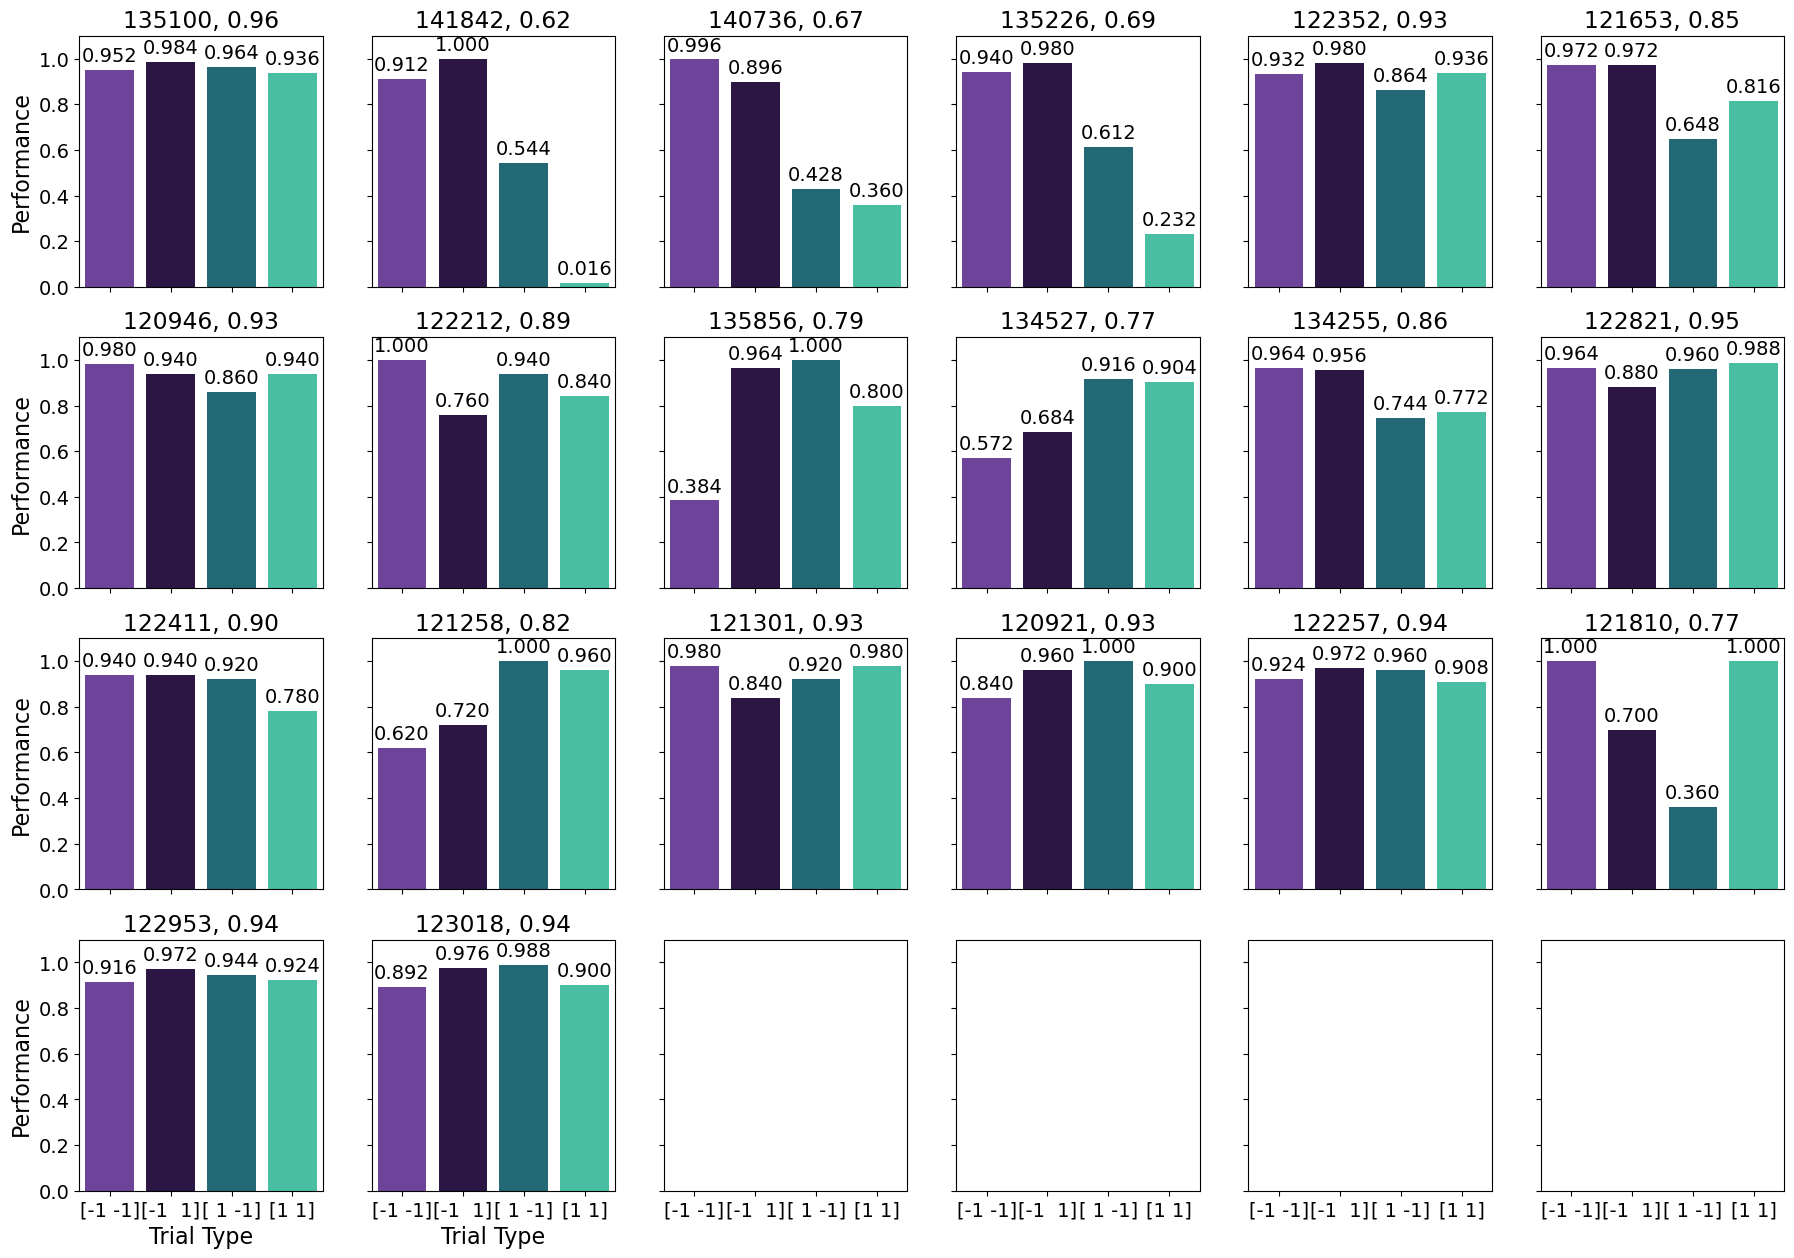

In [13]:
importlib.reload(bhv)

# make all font sizes larger
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model],
                               all_models_dir=all_models_dir)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    axs[i_model].set_title(f'{model_name[-6:]}, {np.mean(trial_perfs):.2f}')

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 6 != 0:
        axs[i].set_ylabel('')
    if i < 18:
        axs[i].set_xlabel('')
    
    
# fig.suptitle(f'Jittered Models Performance for {condn_phrase} {condn_num}', fontsize=20)
plt.show()

#### compare no noise and noise std 1

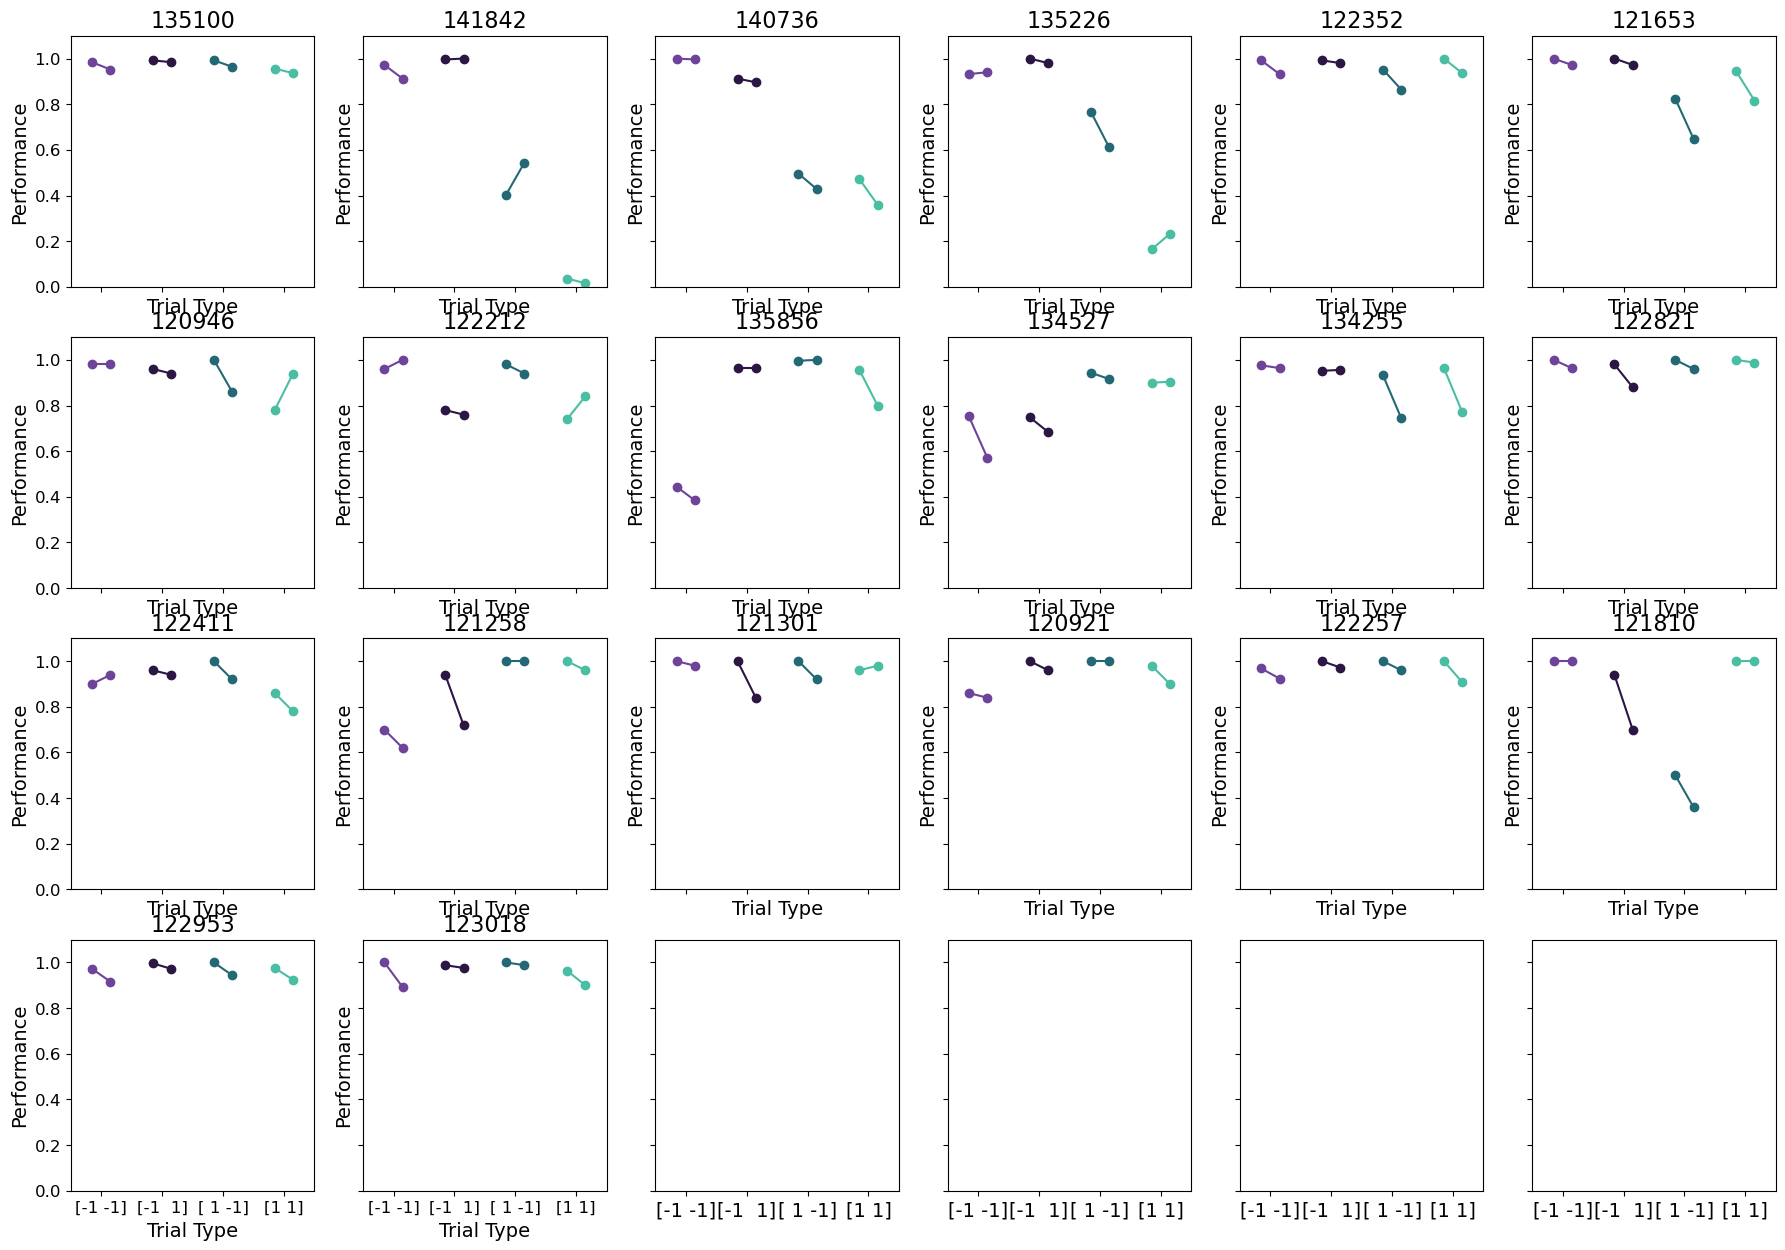

In [14]:
# plot paired comparison of performance for delay=400 and delay=400noisegaussianhalf
importlib.reload(bhv)
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    bhv.plot_paired_trial_performance(model_name, 'delay400.', '', 'delay400noisegaussian1', '',
                                axs[i_model], title=model_name[-6:], all_models_dir=all_models_dir,
                                text=False)

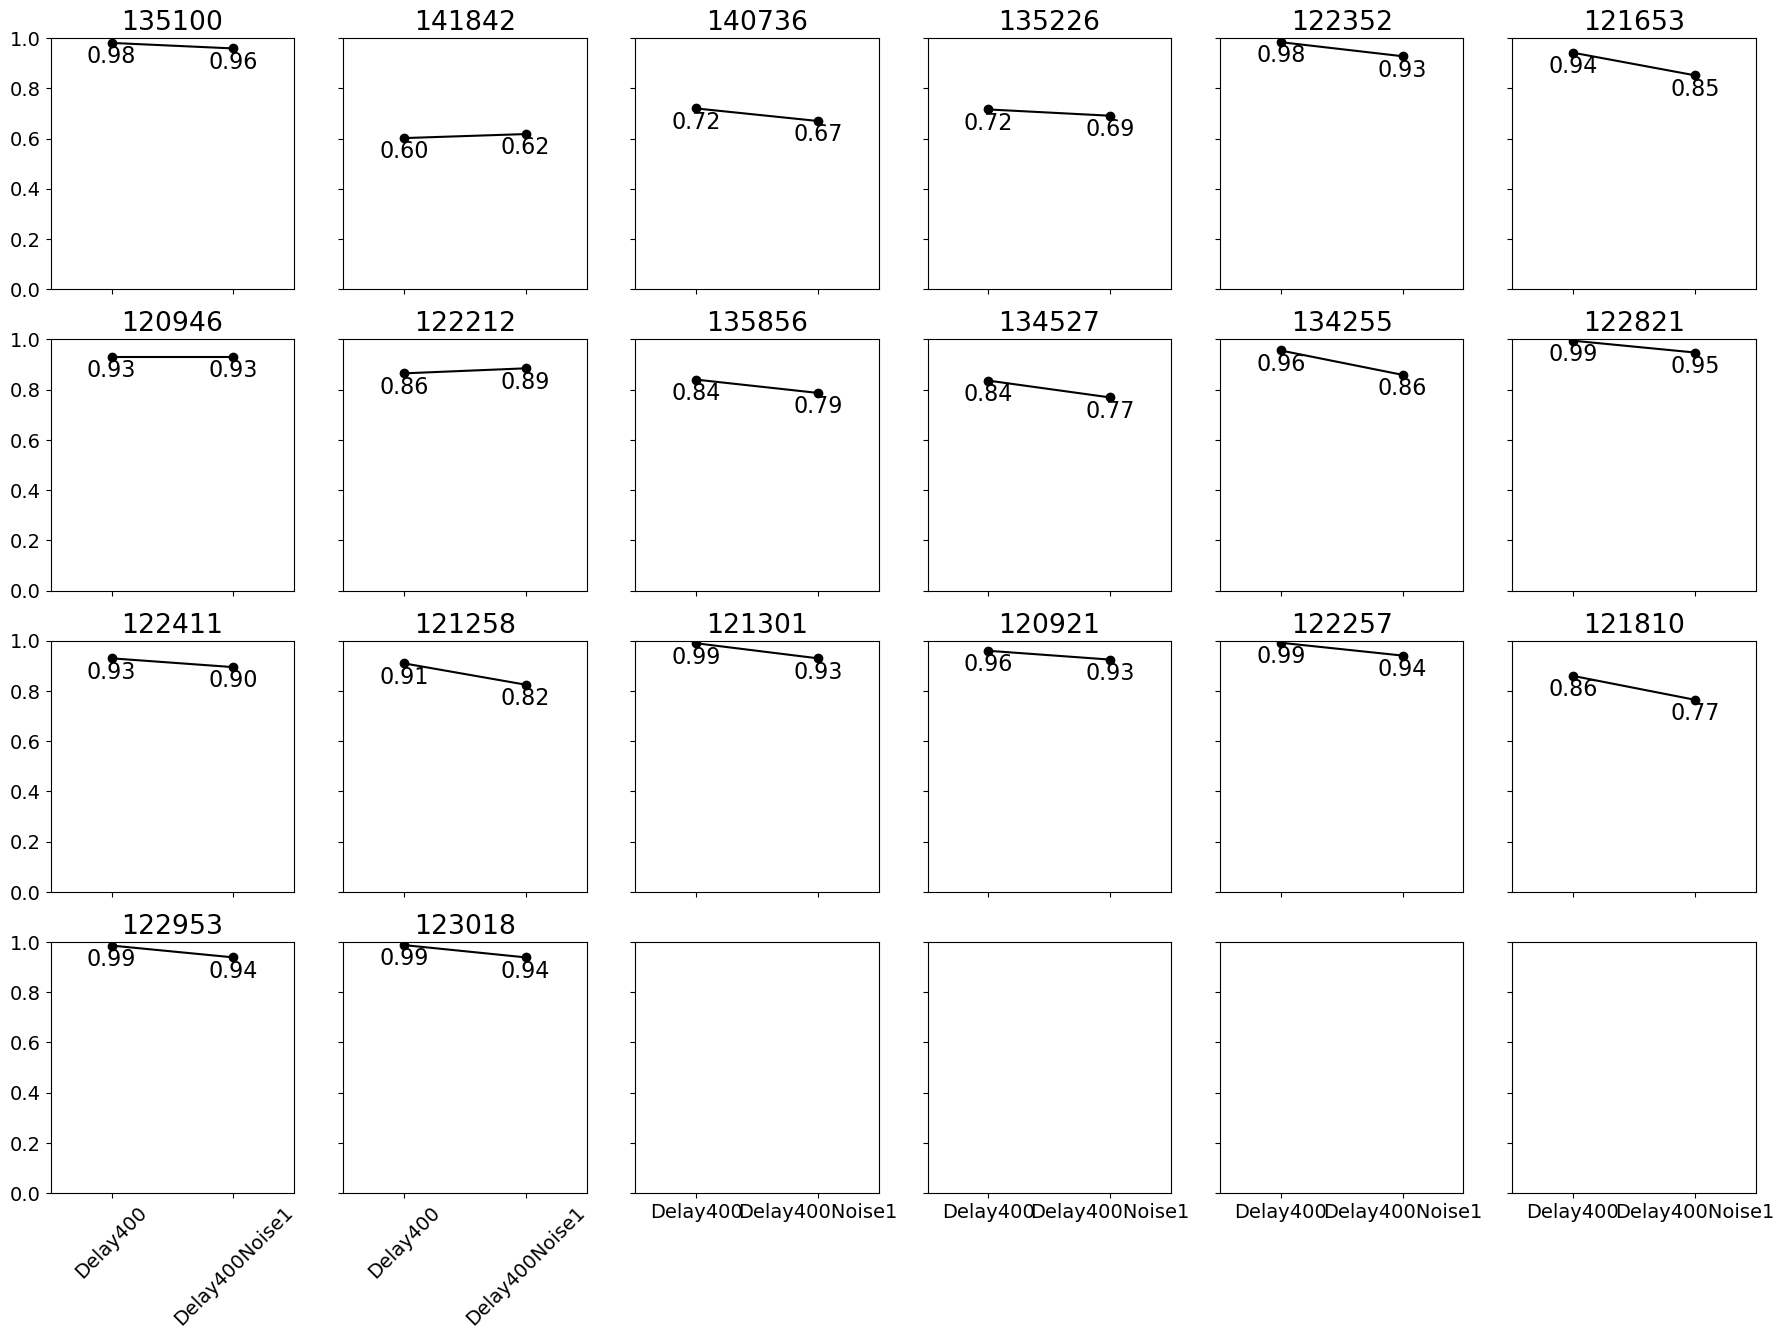

In [15]:
# plot changes in overall model performance

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    _, trial_perfs_400 = ld.load_bhv_data(model_name, 'delay400.', all_models_dir=all_models_dir)
    _, trial_perfs_400_noise = ld.load_bhv_data(model_name, 'delay400noisegaussian1', all_models_dir=all_models_dir)
    axs[i_model].plot([1.25,1.75], [trial_perfs_400.mean(), trial_perfs_400_noise.mean()],
             marker='o', color='black', label=model_name[-6:])
    axs[i_model].text(1.25, trial_perfs_400.mean() - 0.1,
             f'{trial_perfs_400.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.75, trial_perfs_400_noise.mean() - 0.1,
             f'{trial_perfs_400_noise.mean():.2f}', ha='center', va='bottom')
    axs[i_model].set_title(model_name[-6:])
    axs[i_model].set_ylim(0, 1.0)
    axs[i_model].set_xlim(1, 2)
    axs[i_model].set_xticks([1.25, 1.75])
    axs[i_model].set_xticklabels(['Delay400', 'Delay400Noise1'], rotation=45)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
plt.show()

Wilcoxon signed-rank test: stat=3.0, p=0.00021335450001211975


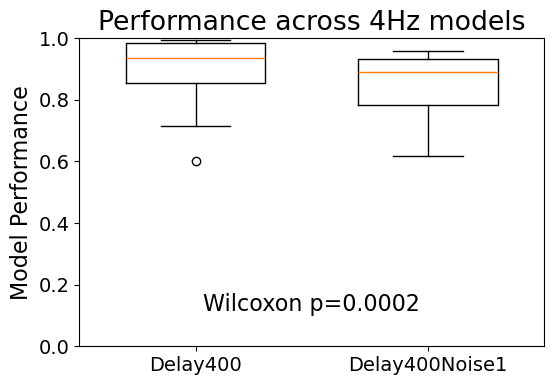

In [16]:
# boxplot comparing differences in perf across models

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
plt.figure(figsize=(6,4))
perfs_400 = np.zeros(len(theta4_models))
perfs_400_noise = np.zeros(len(theta4_models))
for i_model, model_name in enumerate(theta4_models):
    _, trial_perfs_400 = ld.load_bhv_data(model_name, 'delay400.', all_models_dir=all_models_dir)
    _, trial_perfs_400_noise = ld.load_bhv_data(model_name, 'delay400noisegaussian1', all_models_dir=all_models_dir)
    perfs_400[i_model] = trial_perfs_400.mean()
    perfs_400_noise[i_model] = trial_perfs_400_noise.mean()
data = [perfs_400, perfs_400_noise]
plt.boxplot(data, positions=[1, 2], widths=0.6)
plt.xticks([1, 2], ['Delay400', 'Delay400Noise1'])
plt.ylabel('Model Performance')
plt.title('Performance across 4Hz models')
plt.ylim(0, 1.0)

from scipy.stats import wilcoxon
stat, p = wilcoxon(perfs_400, perfs_400_noise)
plt.text(1.5, 0.1, f'Wilcoxon p={p:.4f}', ha='center', va='bottom')


print(f'Wilcoxon signed-rank test: stat={stat}, p={p}')
plt.show()

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
plt.show()

### delay 400 + gaussian noise std 1 + phase shifts up to 1 cycle

In [17]:
condn_phrase = 'delay400noisegaussian1phaseshift1'
condn_num = ''

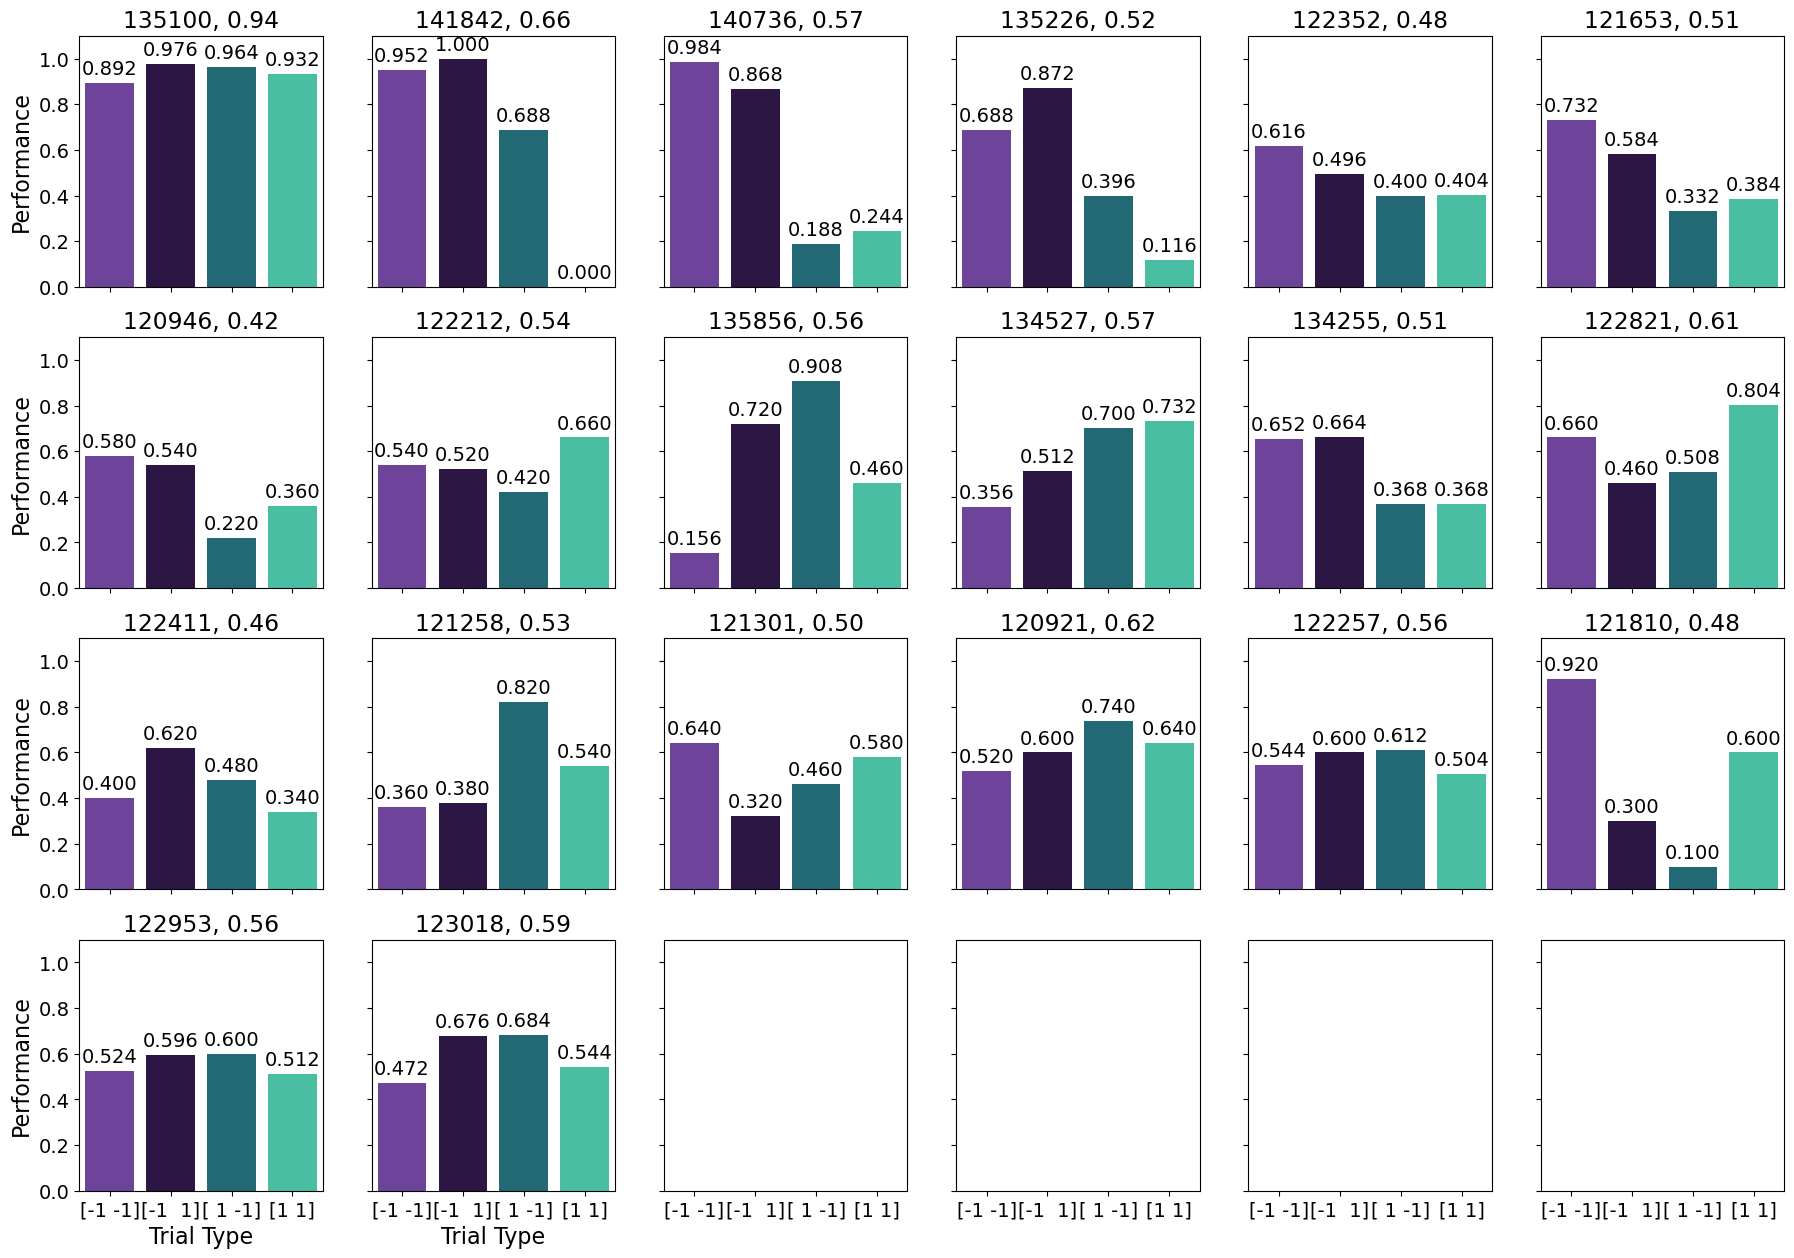

In [19]:
importlib.reload(bhv)

# make all font sizes larger
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model],
                               all_models_dir=all_models_dir)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    axs[i_model].set_title(f'{model_name[-6:]}, {np.mean(trial_perfs):.2f}')

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 6 != 0:
        axs[i].set_ylabel('')
    if i < 18:
        axs[i].set_xlabel('')
    
    
# fig.suptitle(f'Jittered Models Performance for {condn_phrase} {condn_num}', fontsize=20)
plt.show()

### compare gaussian noise std=1 only and that + phase shifts

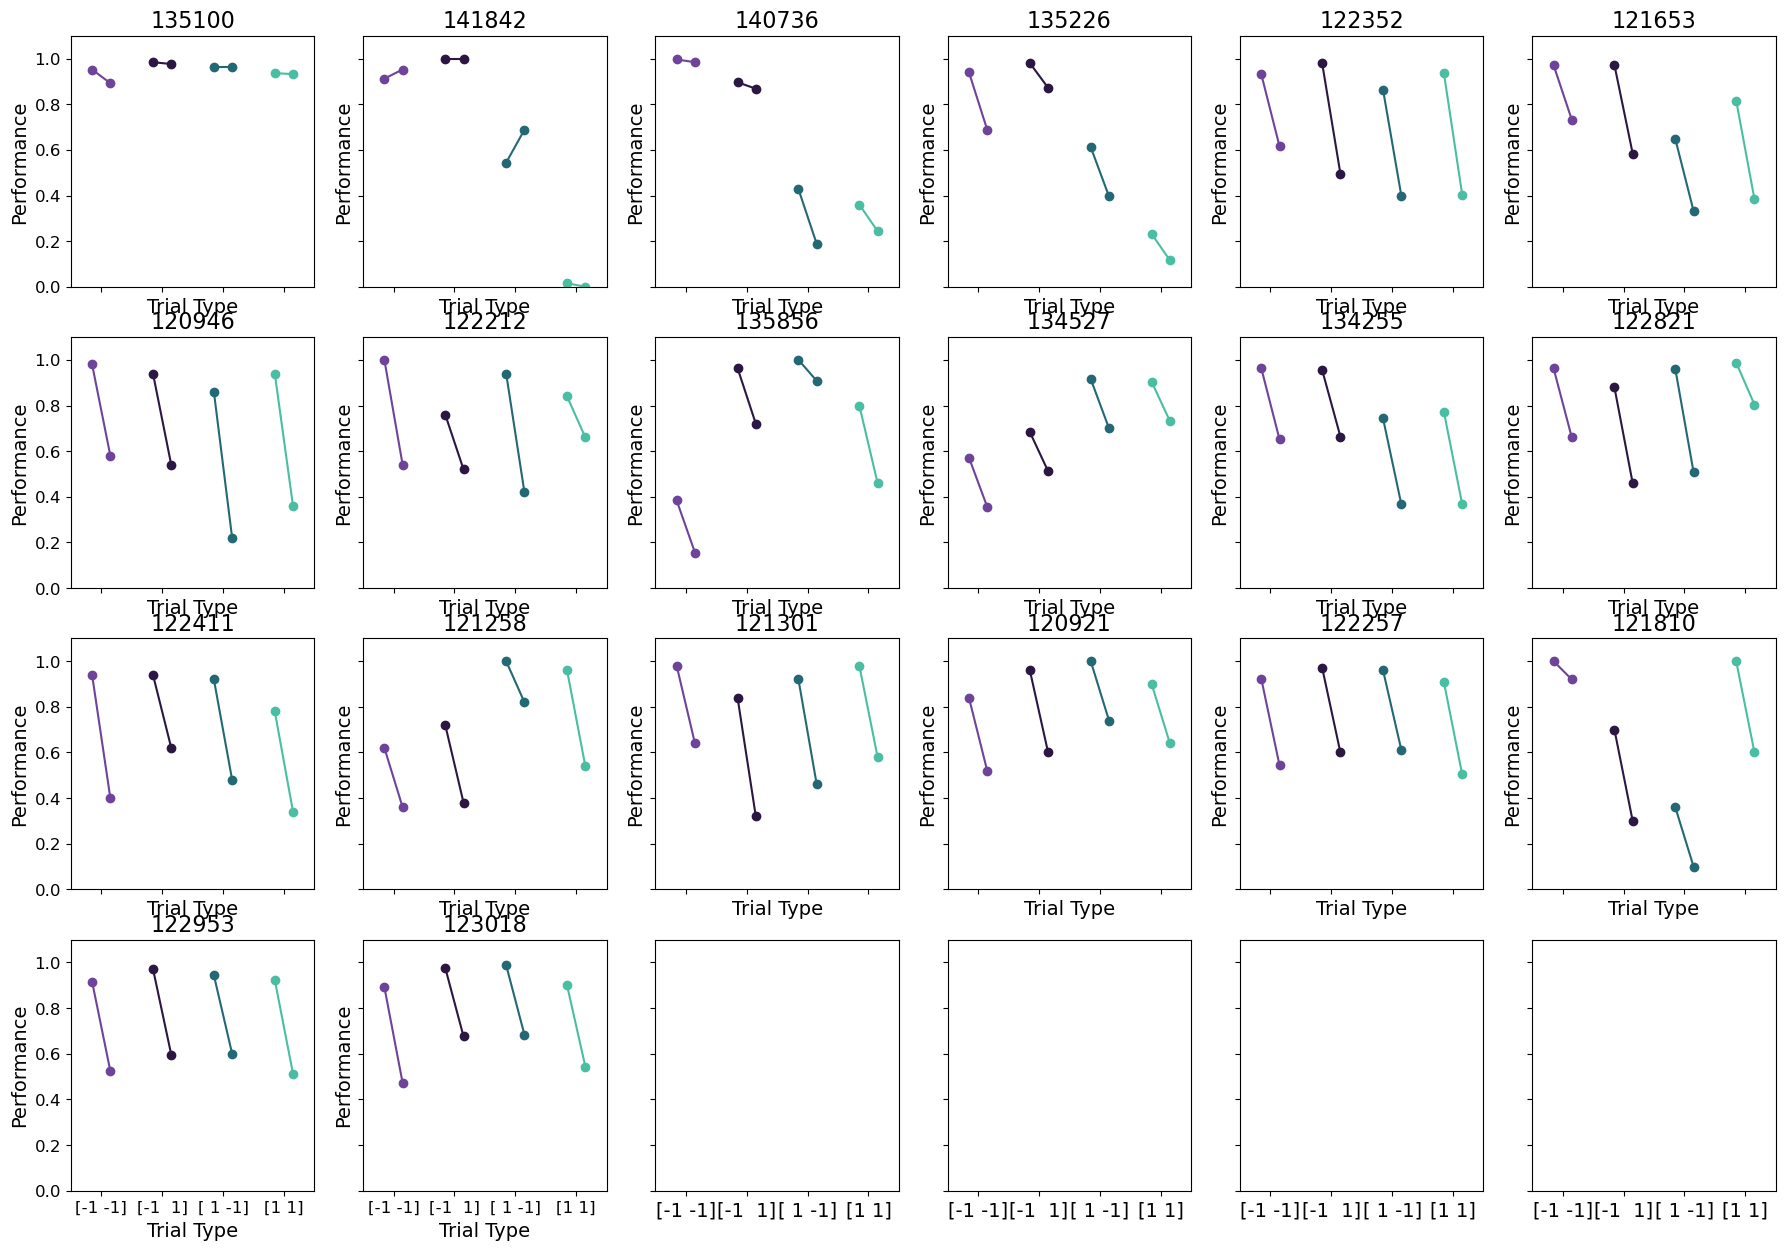

In [20]:
# plot paired comparison of performance for delay=400 and delay=400noisegaussianhalf
importlib.reload(bhv)
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    bhv.plot_paired_trial_performance(model_name, 'delay400noisegaussian1.', '', 'delay400noisegaussian1phaseshift1', '',
                                axs[i_model], title=model_name[-6:], all_models_dir=all_models_dir,
                                text=False)

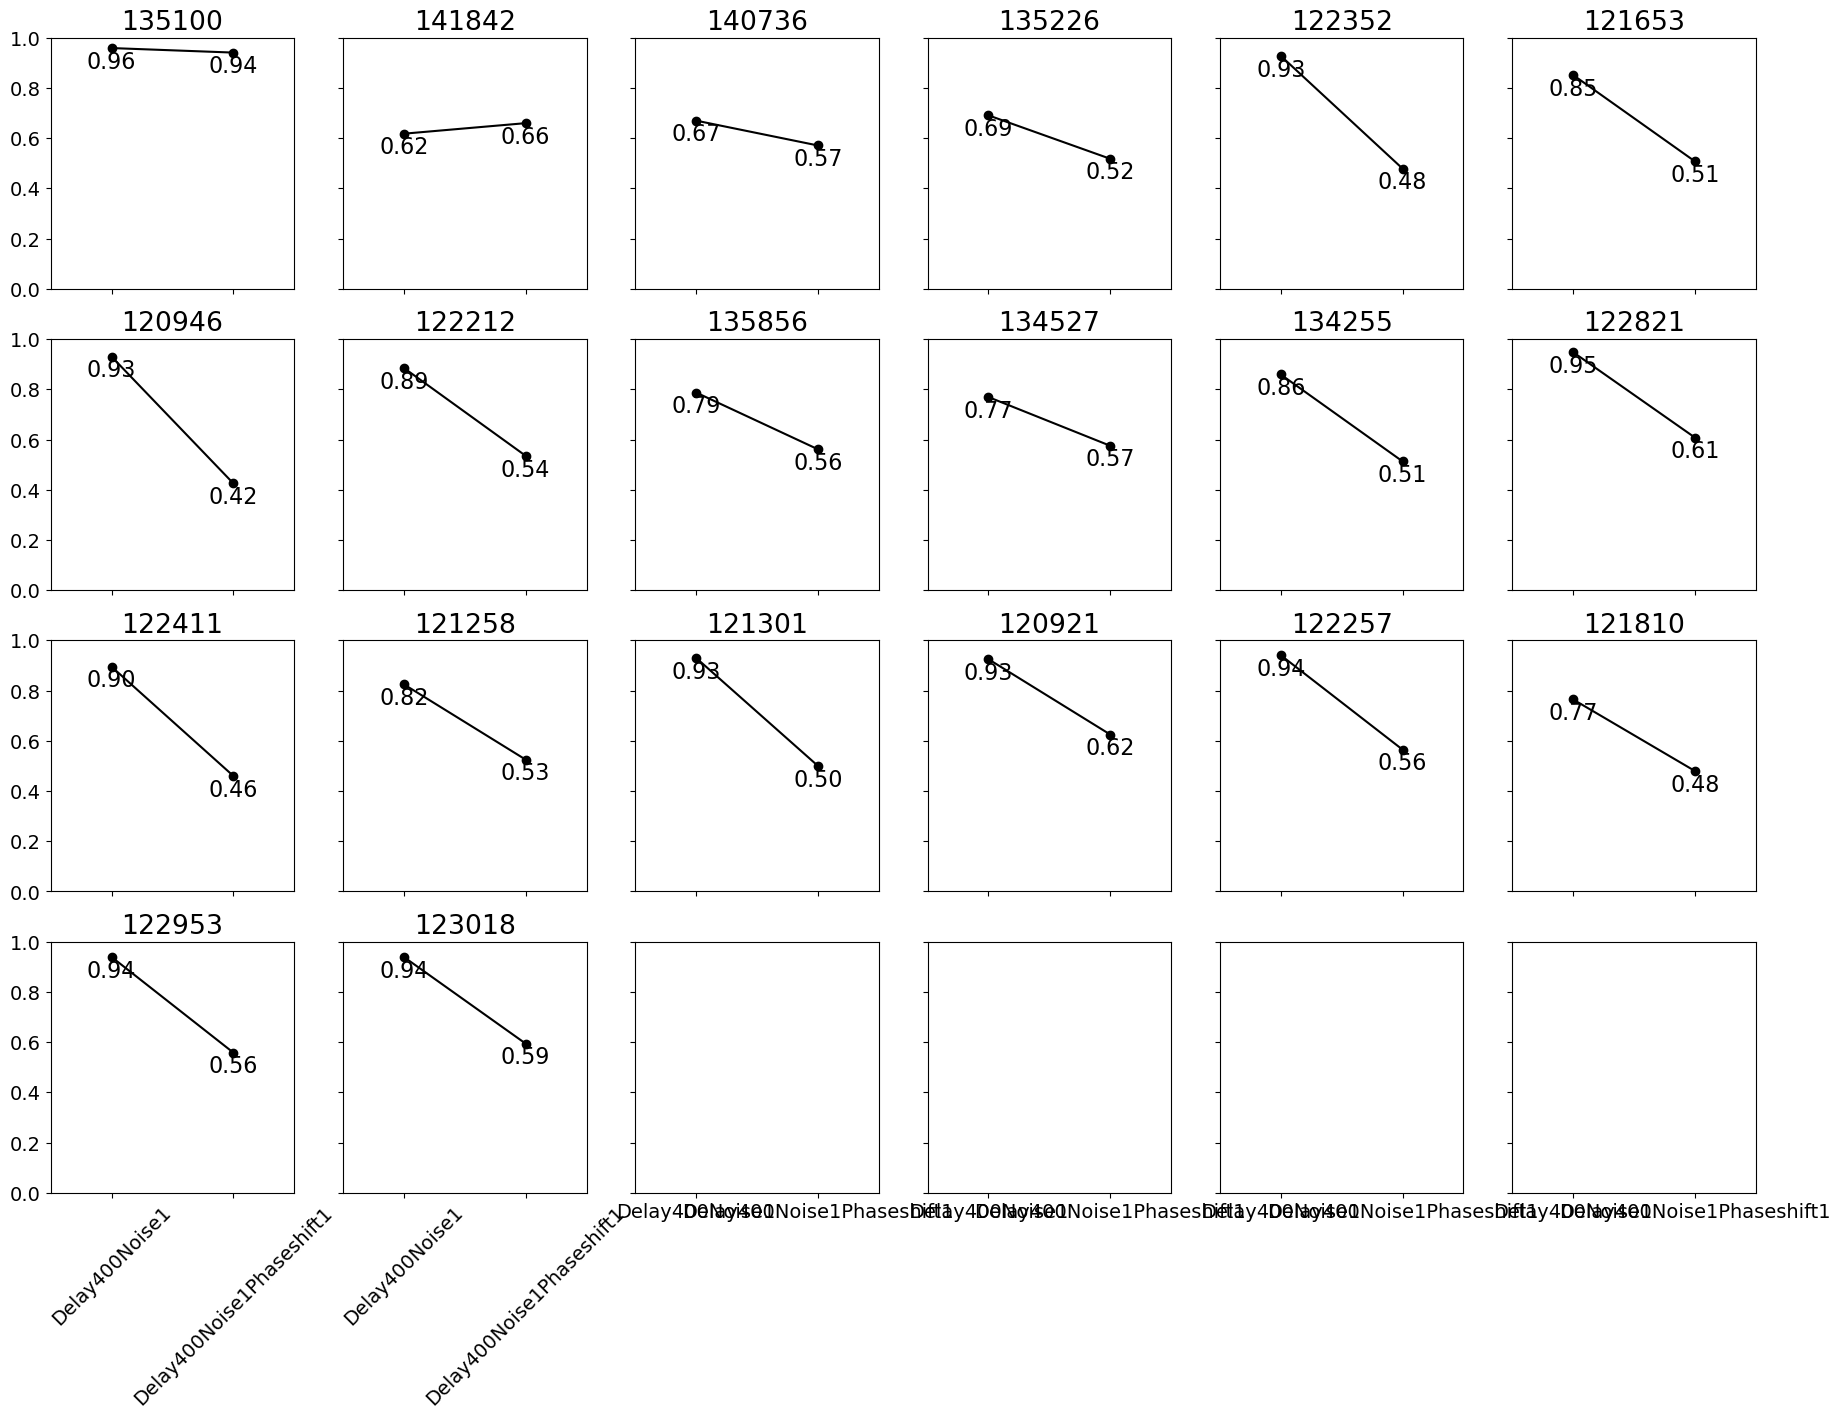

In [21]:
# plot changes in overall model performance

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    _, trial_perfs_400_noise = ld.load_bhv_data(model_name, 'delay400noisegaussian1.', all_models_dir=all_models_dir)
    _, trial_perfs_400_noise_phase = ld.load_bhv_data(model_name, 'delay400noisegaussian1phaseshift1', all_models_dir=all_models_dir)
    axs[i_model].plot([1.25,1.75], [trial_perfs_400_noise.mean(), trial_perfs_400_noise_phase.mean()],
             marker='o', color='black', label=model_name[-6:])
    axs[i_model].text(1.25, trial_perfs_400_noise.mean() - 0.1,
             f'{trial_perfs_400_noise.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.75, trial_perfs_400_noise_phase.mean() - 0.1,
             f'{trial_perfs_400_noise_phase.mean():.2f}', ha='center', va='bottom')
    axs[i_model].set_title(model_name[-6:])
    axs[i_model].set_ylim(0, 1.0)
    axs[i_model].set_xlim(1, 2)
    axs[i_model].set_xticks([1.25, 1.75])
    axs[i_model].set_xticklabels(['Delay400Noise1', 'Delay400Noise1Phaseshift1'], rotation=45)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
plt.show()

Wilcoxon signed-rank test: stat=2.0, p=5.7220458984375e-06


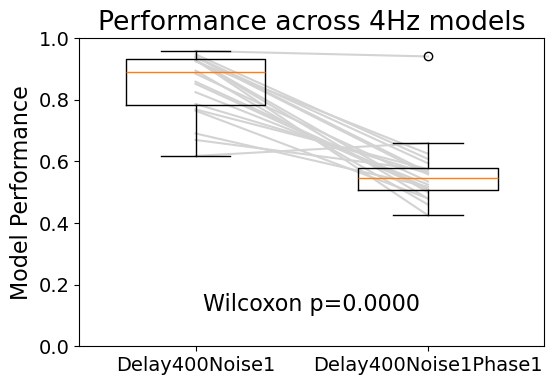

In [22]:
# boxplot comparing differences in perf across models

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
plt.figure(figsize=(6,4))
perfs_400_noise = np.zeros(len(theta4_models))
perfs_400_noisephase = np.zeros(len(theta4_models))
for i_model, model_name in enumerate(theta4_models):
    _, trial_perfs_400 = ld.load_bhv_data(model_name, 'delay400noisegaussian1.', all_models_dir=all_models_dir)
    _, trial_perfs_400_noise = ld.load_bhv_data(model_name, 'delay400noisegaussian1phaseshift1', all_models_dir=all_models_dir)
    perfs_400_noise[i_model] = trial_perfs_400.mean()
    perfs_400_noisephase[i_model] = trial_perfs_400_noise.mean()
data = [perfs_400_noise, perfs_400_noisephase]
plt.boxplot(data, positions=[1, 2], widths=0.6)
plt.xticks([1, 2], ['Delay400Noise1', 'Delay400Noise1Phase1'])
plt.ylabel('Model Performance')
plt.title('Performance across 4Hz models')
plt.ylim(0, 1.0)

# plot light gray lines connecting paired points
for i in range(len(perfs_400_noise)):
    plt.plot([1, 2], [perfs_400_noise[i], perfs_400_noisephase[i]], color='lightgray', zorder=0)

from scipy.stats import wilcoxon
stat, p = wilcoxon(perfs_400_noise, perfs_400_noisephase)
plt.text(1.5, 0.1, f'Wilcoxon p={p:.4f}', ha='center', va='bottom')


print(f'Wilcoxon signed-rank test: stat={stat}, p={p}')
plt.show()

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 5 != 0:
        axs[i].set_ylabel('')
    if i < 15:
        axs[i].set_xlabel('')
plt.show()

### intrigued to see if amt of phase shift is related to trial performance

In [35]:
import scipy.io as sio

def load_bhv_with_phase(model_name, condn_phrase, all_models_dir):
    model_dir = os.path.join(all_models_dir, model_name)
    bhvdata_path = ld.find_files_keywords(model_dir, ['bhvdata', condn_phrase])[0]
    if bhvdata_path == []:
        print(f'No behavioral data found for {model_name} with condition {condn_phrase}{condn_num}')
        return None, None

    # Load the data
    bhv_mat = sio.loadmat(bhvdata_path)
    trial_labels = bhv_mat['all_trial_labels']
    trial_perfs = bhv_mat['all_trial_perfs'].flatten()
    trial_phaseshifts = bhv_mat['all_trial_shifts'].flatten()
    
    return trial_labels, trial_perfs, trial_phaseshifts

#### one model

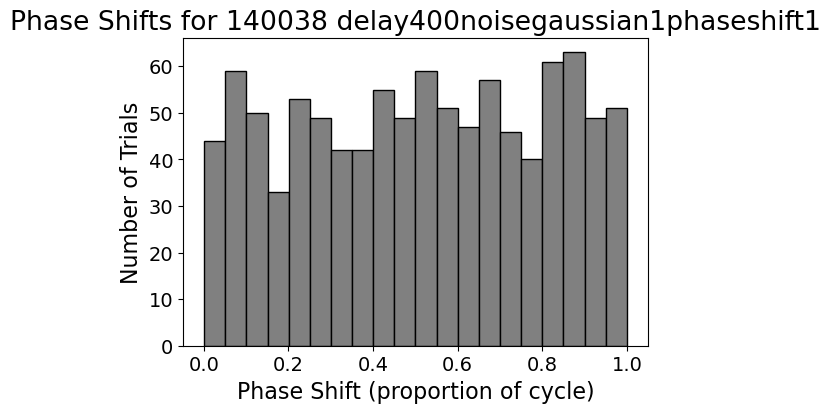

In [41]:
# start with one model

model_name = model_dirs[0]
condn_phrase = 'delay400noisegaussian1phaseshift1'

trial_labels, trial_perfs, trial_phaseshifts = load_bhv_with_phase(model_name, condn_phrase, all_models_dir)

plt.figure(figsize=(6,4))
plt.hist(trial_phaseshifts, bins=20, color='gray', edgecolor='black')
plt.xlabel('Phase Shift (proportion of cycle)')
plt.ylabel('Number of Trials')
plt.title(f'Phase Shifts for {model_name[-6:]} {condn_phrase}')
plt.show()


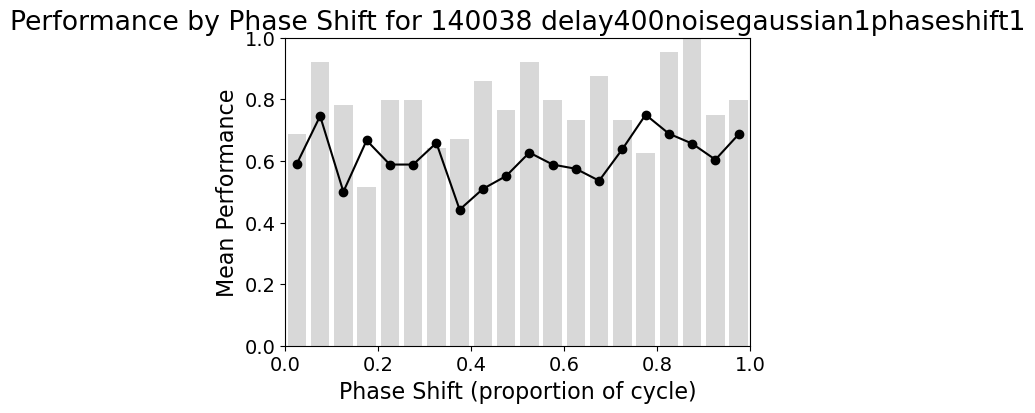

In [46]:
# plot average performance per bin of phase shifts

plt.figure(figsize=(6,4))
bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = np.zeros(len(bin_centers))
bin_counts = np.zeros(len(bin_centers))
for i in range(len(bins)-1):
    in_bin = (trial_phaseshifts >= bins[i]) & (trial_phaseshifts < bins[i+1])
    if np.sum(in_bin) > 0:
        bin_means[i] = np.mean(trial_perfs[in_bin])
        bin_counts[i] = np.sum(in_bin)
    else:
        bin_means[i] = np.nan
plt.plot(bin_centers, bin_means, marker='o', color='black')
plt.bar(bin_centers, bin_counts/bin_counts.max(), width=0.04, alpha=0.3, color='gray', label='Trial Count (normalized)')
plt.xlabel('Phase Shift (proportion of cycle)')
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift for {model_name[-6:]} {condn_phrase}')
plt.ylim(0, 1.0)
plt.xlim(0, 1.0)
plt.show()

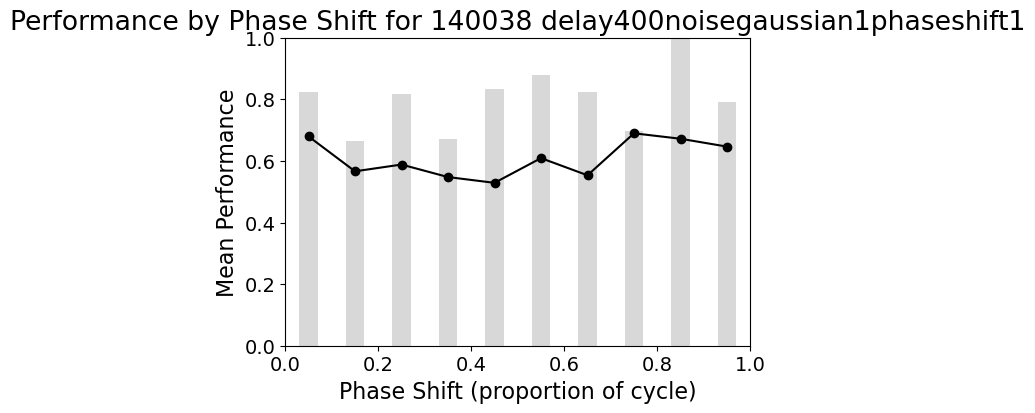

In [47]:
# plot average performance per bin of phase shifts

plt.figure(figsize=(6,4))
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = np.zeros(len(bin_centers))
bin_counts = np.zeros(len(bin_centers))
for i in range(len(bins)-1):
    in_bin = (trial_phaseshifts >= bins[i]) & (trial_phaseshifts < bins[i+1])
    if np.sum(in_bin) > 0:
        bin_means[i] = np.mean(trial_perfs[in_bin])
        bin_counts[i] = np.sum(in_bin)
    else:
        bin_means[i] = np.nan
plt.plot(bin_centers, bin_means, marker='o', color='black')
plt.bar(bin_centers, bin_counts/bin_counts.max(), width=0.04, alpha=0.3, color='gray', label='Trial Count (normalized)')
plt.xlabel('Phase Shift (proportion of cycle)')
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift for {model_name[-6:]} {condn_phrase}')
plt.ylim(0, 1.0)
plt.xlim(0, 1.0)
plt.show()

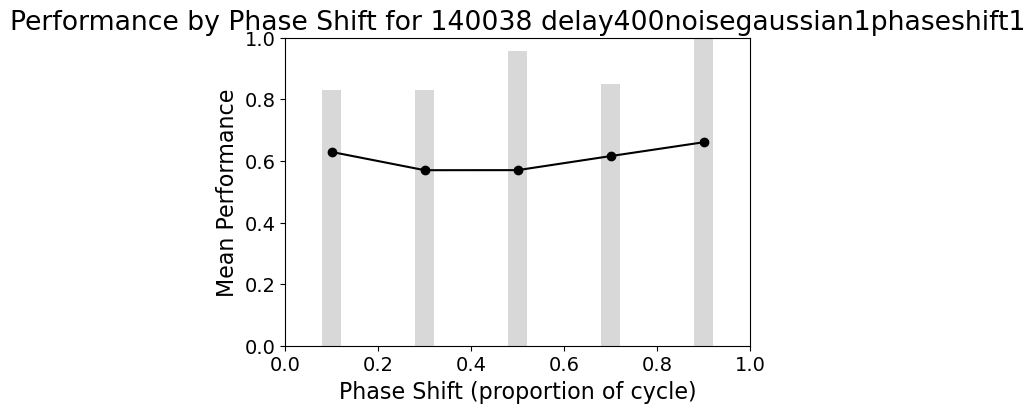

In [48]:
# plot average performance per bin of phase shifts

plt.figure(figsize=(6,4))
bins = np.linspace(0, 1, 6)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = np.zeros(len(bin_centers))
bin_counts = np.zeros(len(bin_centers))
for i in range(len(bins)-1):
    in_bin = (trial_phaseshifts >= bins[i]) & (trial_phaseshifts < bins[i+1])
    if np.sum(in_bin) > 0:
        bin_means[i] = np.mean(trial_perfs[in_bin])
        bin_counts[i] = np.sum(in_bin)
    else:
        bin_means[i] = np.nan
plt.plot(bin_centers, bin_means, marker='o', color='black')
plt.bar(bin_centers, bin_counts/bin_counts.max(), width=0.04, alpha=0.3, color='gray', label='Trial Count (normalized)')
plt.xlabel('Phase Shift (proportion of cycle)')
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift for {model_name[-6:]} {condn_phrase}')
plt.ylim(0, 1.0)
plt.xlim(0, 1.0)
plt.show()

Small shift mean perf: 0.65, n=501
Large shift mean perf: 0.57, n=499


(0.0, 1.0)

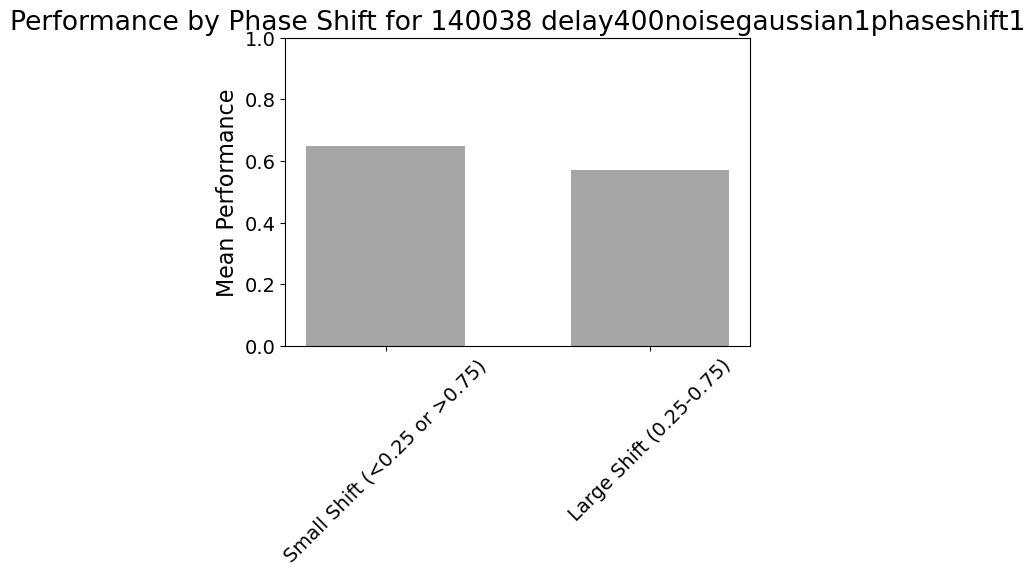

In [51]:
# plot average performance per bin of phase shifts

plt.figure(figsize=(6,4))
small_shift = (trial_phaseshifts < 0.25) | (trial_phaseshifts > 0.75)
large_shift = (trial_phaseshifts >= 0.25) & (trial_phaseshifts <= 0.75)
print(f'Small shift mean perf: {trial_perfs[small_shift].mean():.2f}, n={np.sum(small_shift)}')
print(f'Large shift mean perf: {trial_perfs[large_shift].mean():.2f}, n={np.sum(large_shift)}')

plt.bar([1, 2], [trial_perfs[small_shift].mean(), trial_perfs[large_shift].mean()],
        color='gray', alpha=0.7, width=0.6)
plt.xticks([1, 2], ['Small Shift (<0.25 or >0.75)', 'Large Shift (0.25-0.75)'], rotation=45)
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift for {model_name[-6:]} {condn_phrase}')
plt.ylim(0, 1.0)

#### across models

Wilcoxon signed-rank test: stat=7.0, p=9.059906005859375e-06


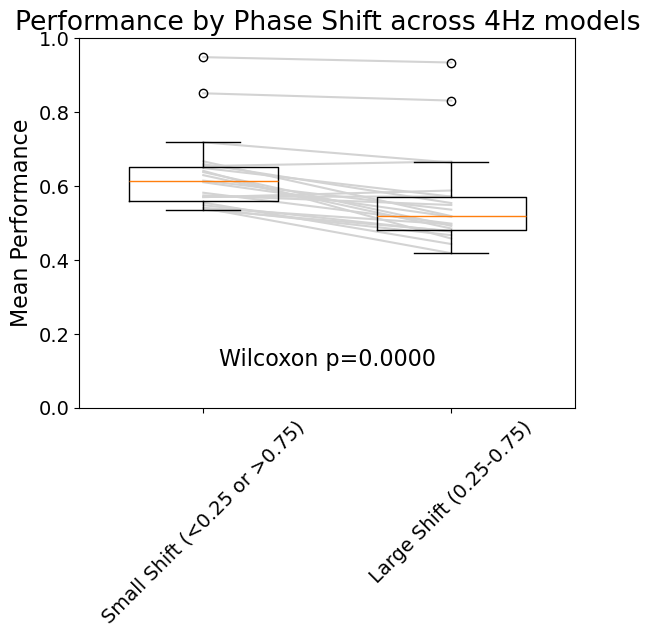

In [ ]:
# loop thru models, splitting into small and large phase shifts

perfs_small = np.zeros(len(theta4_models))
perfs_large = np.zeros(len(theta4_models))

for i_model, model_name in enumerate(theta4_models):
    trial_labels, trial_perfs, trial_phaseshifts = load_bhv_with_phase(model_name, condn_phrase, all_models_dir)
    small_shift = (trial_phaseshifts < 0.25) | (trial_phaseshifts > 0.75)
    large_shift = (trial_phaseshifts >= 0.25) & (trial_phaseshifts <= 0.75)
    perfs_small[i_model] = trial_perfs[small_shift].mean()
    perfs_large[i_model] = trial_perfs[large_shift].mean()
    
data = [perfs_small, perfs_large]
plt.boxplot(data, positions=[1, 2], widths=0.6)
plt.xticks([1, 2], ['Small Shift (<0.25 or >0.75)', 'Large Shift (0.25-0.75)'], rotation=45)
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift across 4Hz models')
plt.ylim(0, 1.0)

# plot light gray lines connecting paired points
for i in range(len(perfs_small)):
    plt.plot([1, 2], [perfs_small[i], perfs_large[i]], color='lightgray', zorder=0)
    
from scipy.stats import wilcoxon
stat, p = wilcoxon(perfs_small, perfs_large)
plt.text(1.5, 0.1, f'Wilcoxon p={p:.4f}', ha='center', va='bottom')

print(f'Wilcoxon signed-rank test: stat={stat}, p={p}')
plt.show()


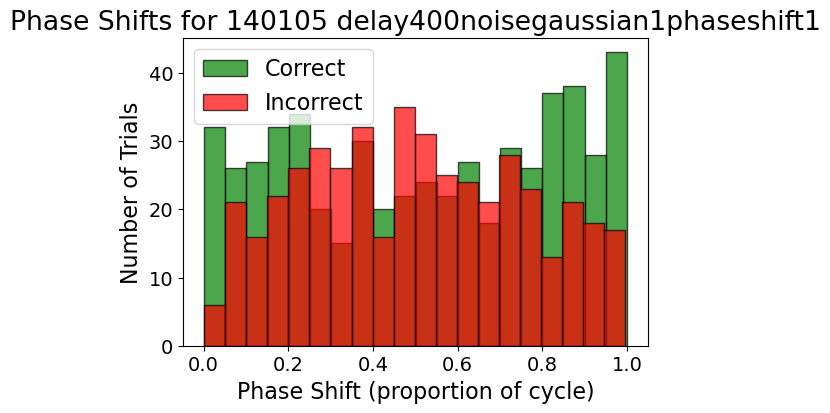

In [53]:
# plot cycle shift for correct vs incorrect trials

plt.figure(figsize=(6,4))
correct = trial_perfs == 1
incorrect = trial_perfs == 0
plt.hist(trial_phaseshifts[correct], bins=20, color='green', alpha=0.7, label='Correct', edgecolor='black')
plt.hist(trial_phaseshifts[incorrect], bins=20, color='red', alpha=0.7, label='Incorrect', edgecolor='black')
plt.xlabel('Phase Shift (proportion of cycle)')
plt.ylabel('Number of Trials')
plt.title(f'Phase Shifts for {model_name[-6:]} {condn_phrase}')
plt.legend()
plt.show()

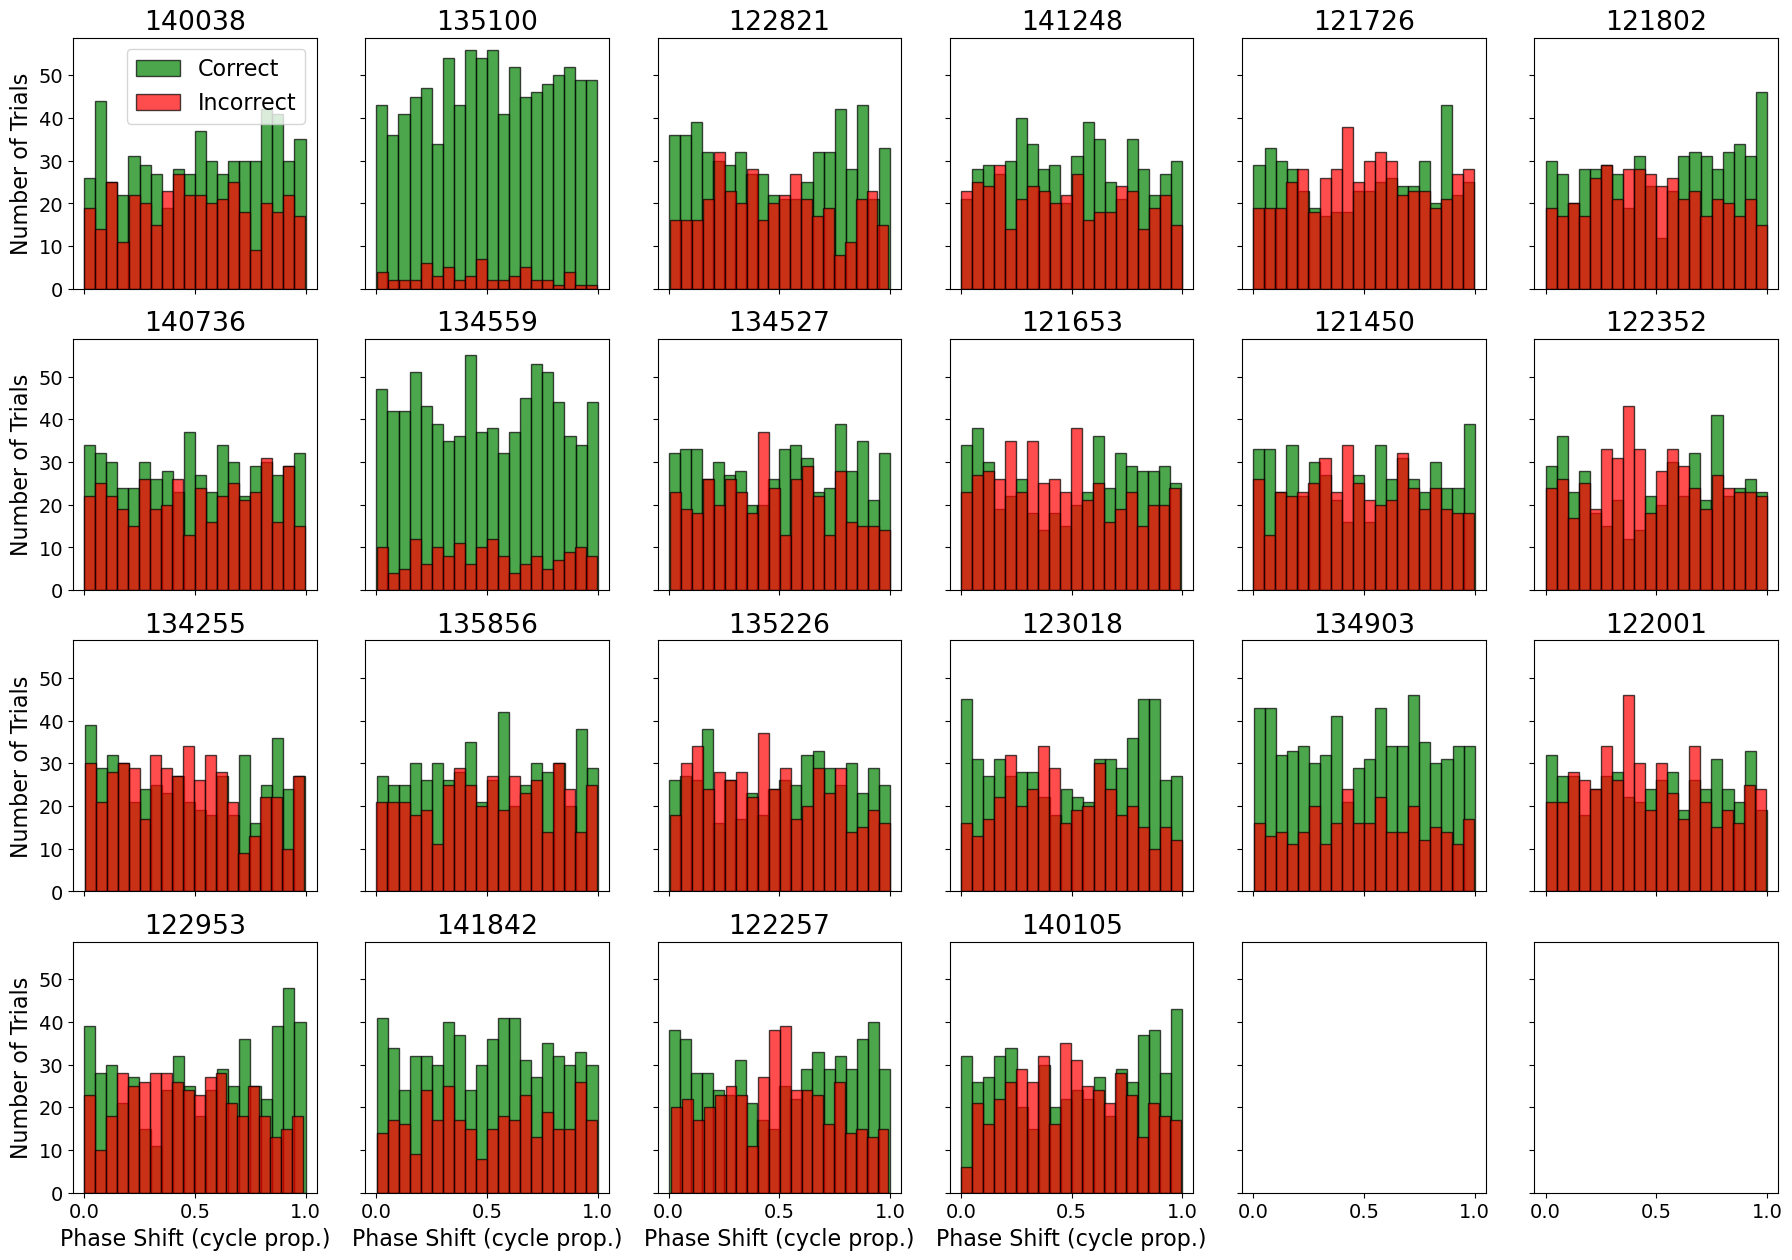

In [56]:
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    trial_labels, trial_perfs, trial_phaseshifts = load_bhv_with_phase(model_name, condn_phrase, all_models_dir)
    correct = trial_perfs == 1
    incorrect = trial_perfs == 0
    axs[i_model].hist(trial_phaseshifts[correct], bins=20, color='green', alpha=0.7, label='Correct', edgecolor='black')
    axs[i_model].hist(trial_phaseshifts[incorrect], bins=20, color='red', alpha=0.7, label='Incorrect', edgecolor='black')
    axs[i_model].set_title(f'{model_name[-6:]}')
    if i_model == 0:
        axs[i_model].legend()
    
    axs[i_model].set_xlabel('Phase Shift (cycle prop.)')
    axs[i_model].set_ylabel('Number of Trials')
    if i_model % 6 != 0:
        axs[i_model].set_ylabel('')
    if i_model < 18:
        axs[i_model].set_xlabel('')
plt.show()

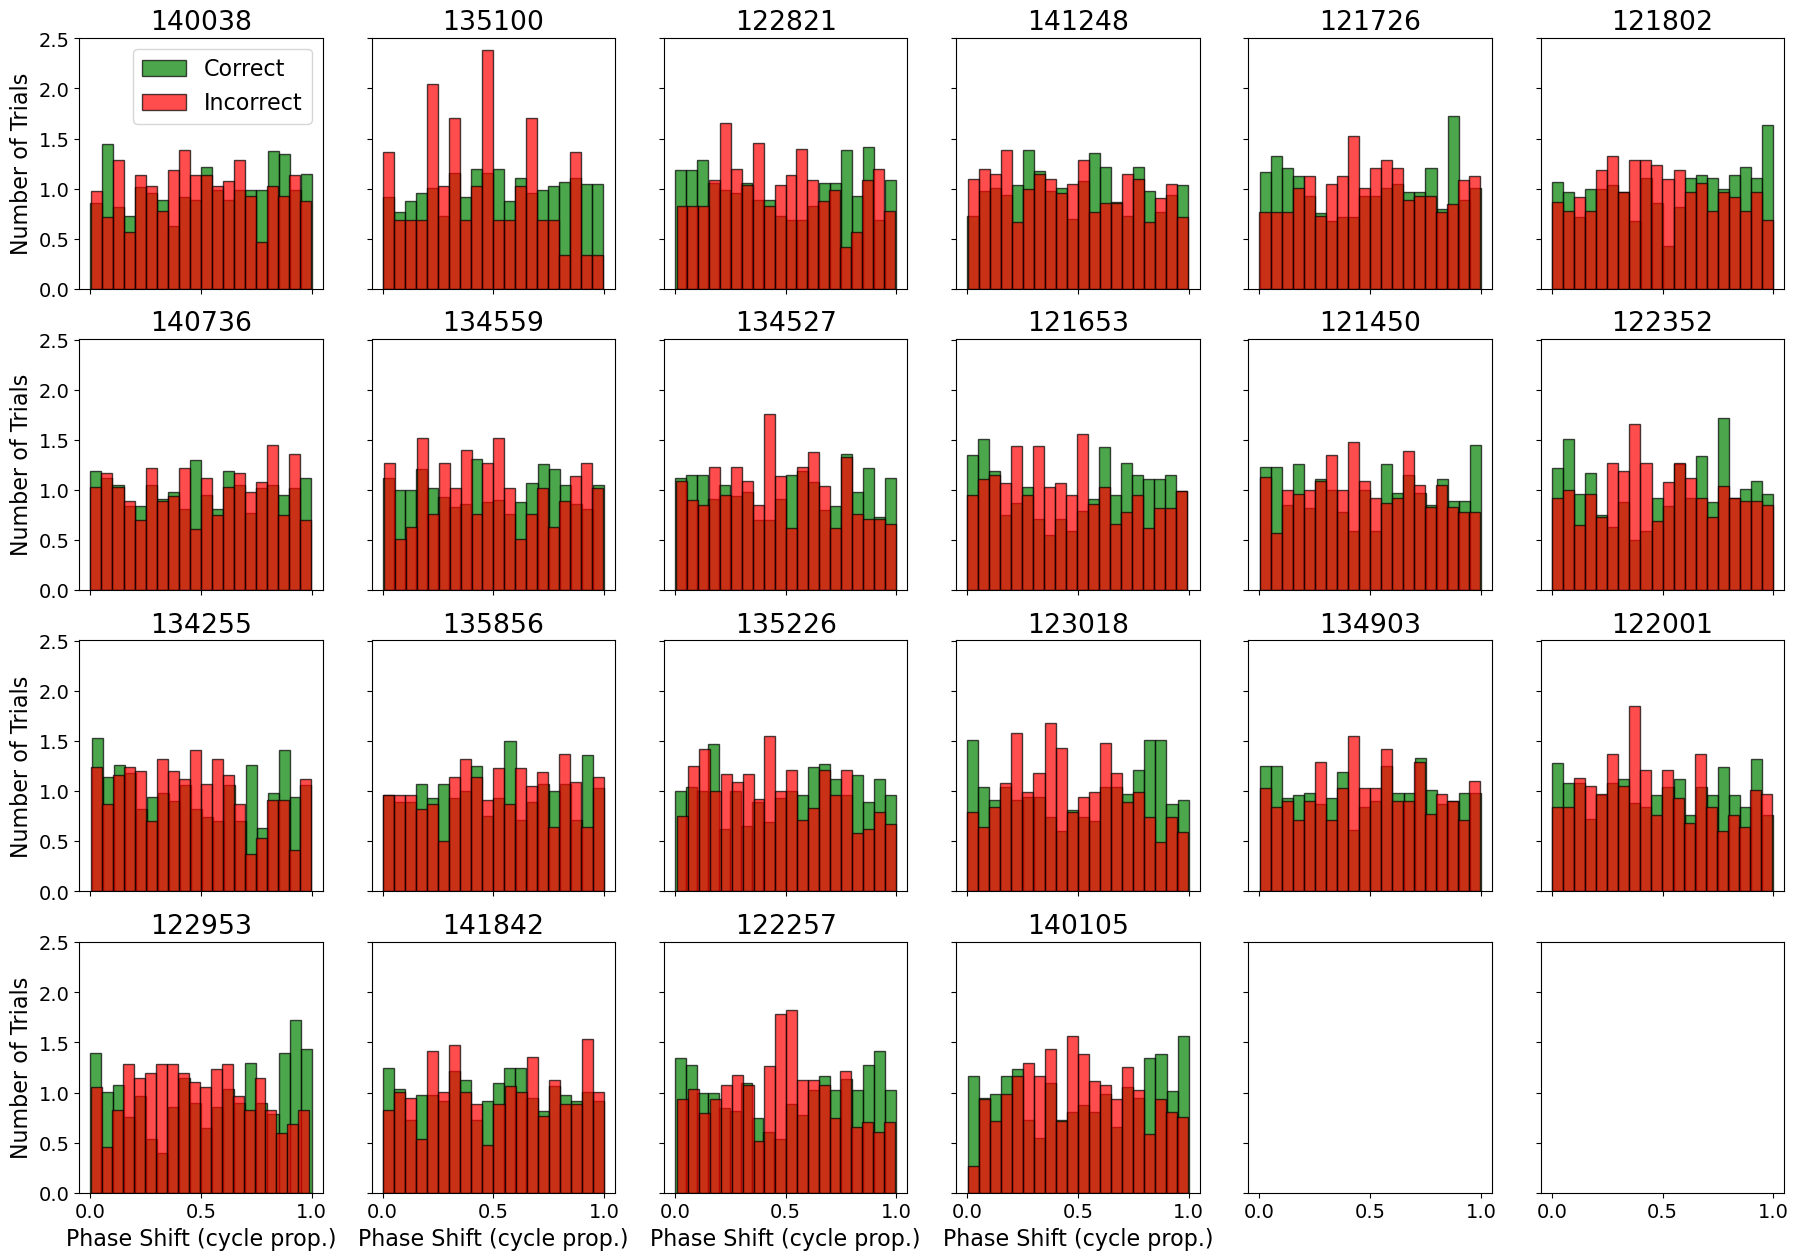

In [57]:
# same but normalize histograms 

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_models):
    trial_labels, trial_perfs, trial_phaseshifts = load_bhv_with_phase(model_name, condn_phrase, all_models_dir)
    correct = trial_perfs == 1
    incorrect = trial_perfs == 0
    axs[i_model].hist(trial_phaseshifts[correct], bins=20, color='green', alpha=0.7, label='Correct', edgecolor='black', density=True)
    axs[i_model].hist(trial_phaseshifts[incorrect], bins=20, color='red', alpha=0.7, label='Incorrect', edgecolor='black', density=True)
    axs[i_model].set_title(f'{model_name[-6:]}')
    if i_model == 0:
        axs[i_model].legend()
    
    axs[i_model].set_xlabel('Phase Shift (cycle prop.)')
    axs[i_model].set_ylabel('Number of Trials')
    if i_model % 6 != 0:
        axs[i_model].set_ylabel('')
    if i_model < 18:
        axs[i_model].set_xlabel('')
plt.show()